# Cholesterol Value Predictor (Traditional Machine Learning) - framingham dataset

### 1) Import Libraries

In [2]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/framingham_dataset"

#----- Tools, visualizers -----
from utils import *
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

#----- Preprocessing -----
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

#----- Models -----
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso,\
      ElasticNet, RANSACRegressor, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,\
      AdaBoostRegressor, ExtraTreesRegressor

#----- Variables -----
RANDOM_STATE = 42



### 2) Load Data

In [3]:
# Load train set
#---------------
data = pd.read_csv(DATA_DIR / "framingham_train_set.csv")
test = pd.read_csv(DATA_DIR / "framingham_test_set.csv")

data.shape, test.shape

((3604, 16), (636, 16))

### 3) Drop Invalid Rows

In [4]:
# totChol, sysBP and diaBP have few unlikely values that should be removed

data = drop_rows_outside_valid_range(data, 'totChol', upper=500)
test = drop_rows_outside_valid_range(test, 'totChol', upper=500)

data = drop_rows_outside_valid_range(data, 'sysBP', upper=250)
test = drop_rows_outside_valid_range(test, 'sysBP', upper=250)

data = drop_rows_outside_valid_range(data, 'diaBP', upper=140)
test = drop_rows_outside_valid_range(test, 'diaBP', upper=140)


# Make sure it's done as expected
def display_invalid_counts(X):
    #--totChol--
    print('totChol:')
    print(f"Counts of (< 80): {(X['totChol'] <= 80).sum()}",
            f"\nCounts of (> 500): {(X['totChol'] >= 500).sum()}\n{20*'--'}")

    #--sysBP--
    print('sysBP:')
    print(f"Counts of (< 80): {(X['sysBP'] <= 80).sum()}",
            f"\nCounts of (> 250): {(X['sysBP'] >= 250).sum()}\n{20*'--'}")

    #--diaBP--
    print('diaBP:')
    print(f"Counts of (< 40): {(X['diaBP'] <= 40).sum()}",
            f"\nCounts of (> 140): {(X['diaBP'] >= 140).sum()}", end='\n\n')
    

print(f"Shapes after the drops:\n data: {data.shape} | test: {test.shape}", end='\n\n')
print('Data set:')
display_invalid_counts(data)
print('Test set:')
display_invalid_counts(test)


Shapes after the drops:
 data: (3601, 16) | test: (635, 16)

Data set:
totChol:
Counts of (< 80): 0 
Counts of (> 500): 0
----------------------------------------
sysBP:
Counts of (< 80): 0 
Counts of (> 250): 0
----------------------------------------
diaBP:
Counts of (< 40): 0 
Counts of (> 140): 1

Test set:
totChol:
Counts of (< 80): 0 
Counts of (> 500): 0
----------------------------------------
sysBP:
Counts of (< 80): 0 
Counts of (> 250): 0
----------------------------------------
diaBP:
Counts of (< 40): 0 
Counts of (> 140): 0



### 4) Drop rows that there are target's (totchol) missing values

In [5]:
# Drop NaNs
data = data.dropna(subset=['totChol']).reset_index(drop=True)
test = test.dropna(subset=['totChol']).reset_index(drop=True)

# Display 
print(f"Shapes after the drops:\ndata: {data.shape} | test: {test.shape}", end='\n\n')
print(f"Counts of NaNs in data: {data['totChol'].isna().sum()}\nCounts of NaNs in test: {test['totChol'].isna().sum()}")

Shapes after the drops:
data: (3562, 16) | test: (624, 16)

Counts of NaNs in data: 0
Counts of NaNs in test: 0


### 5) Define feature columns and target
> **Target:** totChol


In [6]:
"""
Separate features and target for the regression task.

- Target: `totChol`
- Features: all columns except `totChol`

"""

# -------------------------------------
# totChol as the target
# -------------------------------------

# ---------- DATA ---------

# Separate features and labels cols
X_TRAIN = data.drop(columns=['totChol']) # Features
y_train = data['totChol'] # Labels


# ---------- TEST ---------

# Separate features and labels cols
X_TEST = test.drop(columns=['totChol']) # Features
y_test = test['totChol'] # Labels


# Display shapes
print("----- DONE -----", end='\n\n')
print(f"Shapes:\n\nX_TRAIN: {X_TRAIN.shape} | y_train: {y_train.shape}")
print(f"X_TEST: {X_TEST.shape} | y_test: {y_test.shape}")


----- DONE -----

Shapes:

X_TRAIN: (3562, 15) | y_train: (3562,)
X_TEST: (624, 15) | y_test: (624,)


### 6) Core Feature Engineering

To enhance the predictive representation of clinically relevant variables, a set of targeted feature engineering experiments was conducted prior to preprocessing and model benchmarking. These engineered features were evaluated independently against the baseline feature set using cross-validation in order to determine whether they improved regression performance.

Three main feature-engineering strategies were explored:

1. Smoking Intensity Representation
   The original `cigsPerDay` variable exhibited a highly zero-inflated and right-skewed distribution, primarily because non-smokers were encoded as zero while smokers spanned a wide numerical range. To improve interpretability and potentially reduce distributional skewness, cigarette consumption was transformed into ordinal smoking-intensity categories using clinically interpretable ranges:

* Non-smoker
* Light smoker
* Moderate smoker
* Heavy smoker

This experiment aimed to evaluate whether categorical smoking exposure provided a more effective representation than the original continuous feature.

2. Blood Pressure–Derived Features
   Because systolic blood pressure (`sysBP`) and diastolic blood pressure (`diaBP`) were strongly correlated, additional cardiovascular descriptors were derived to capture complementary physiological information:

* Pulse Pressure (PP), representing the difference between systolic and diastolic pressure.
* Mean Arterial Pressure (MAP), representing average arterial pressure during a cardiac cycle.

These engineered features were added while retaining the original blood pressure variables, allowing the models to evaluate whether the derived hemodynamic measures contributed additional predictive signal.

3. Log Transformation of Glucose
   The `glucose` feature demonstrated substantial positive skewness during exploratory data analysis. To reduce skewness and stabilize extreme values, a logarithmic transformation was applied. This experiment primarily targeted potential improvements in linear regression models, which can be sensitive to highly skewed feature distributions.

Each engineered dataset was stored separately and benchmarked independently against the baseline feature configuration. This modular experimental design enabled systematic evaluation of the contribution of each feature-engineering strategy while preserving reproducibility and preventing uncontrolled feature interactions.


In [7]:

# Experiment 1
def smoking_eng(X, feat='cigsPerDay', drop_feat=False, order=True):
    # Make a copy of X
    x = X.copy()
    # Define new feature
    new_feat = 'Smoking_Intensity'
    # Add the new feature column (Categorizing feat into 4 categories)
    x[new_feat] = pd.cut(x[feat], bins=[-1, 0, 10, 20, x[feat].max()],
                            labels=['non-smoker', 'light', 'moderate', 'heavy'], ordered=order)
    
    if drop_feat:
        x.drop(columns=[feat], inplace=True)

    return x


# Experiment 2
def BP_eng(X, sys='sysBP', dia='diaBP'):
    # Make two copies of X
    x = X.copy()
    # Define new features columns
    pp = 'Pulse_Pressure'
    map_ = 'Mean_Arterial_Pressure'
    
    # Calculate and add PP
    x[pp] = x[sys] - x[dia]

    # Calculate and add MAP
    x[map_] = ((2*x[dia]) + x[sys]) / 3

    return x
    

# Experiment 3
def glucose_log_eng(X, feat='glucose'):
    # Make a copy of X
    x = X.copy()
    # Apply log transfromation on the feature
    x[feat] = np.log1p(x[feat])

    return x

# Apply smoking eng
x_smoking_train = smoking_eng(X_TRAIN)
x_smoking_test = smoking_eng(X_TEST)

# Apply bp eng
x_bp_train = BP_eng(X_TRAIN)
x_bp_test = BP_eng(X_TEST)

# Apply log-transform eng
x_glucose_train = glucose_log_eng(X_TRAIN)
x_glucose_test = glucose_log_eng(X_TEST)

print("----- Feature Engineering Done -----")


----- Feature Engineering Done -----


In [7]:
# Check ex1
x_smoking_train.head(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Smoking_Intensity
0,1,50,1.0,1,20.0,0.0,0,0,0,149.0,96.0,28.55,88.0,NaN,0,moderate
1,0,41,3.0,1,15.0,0.0,0,0,0,120.0,80.0,20.67,86.0,64.0,0,moderate
2,1,65,1.0,1,20.0,0.0,0,1,0,140.0,82.5,21.24,98.0,NaN,0,moderate
3,1,34,3.0,1,20.0,0.0,0,0,0,117.5,72.5,23.51,85.0,65.0,0,moderate
4,0,63,3.0,0,0.0,0.0,0,1,0,153.0,89.0,32.57,65.0,75.0,1,non-smoker


In [8]:
# Check ex2
x_bp_train.head(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Pulse_Pressure,Mean_Arterial_Pressure
0,1,50,1.0,1,20.0,0.0,0,0,0,149.0,96.0,28.55,88.0,NaN,0,53.0,113.666667
1,0,41,3.0,1,15.0,0.0,0,0,0,120.0,80.0,20.67,86.0,64.0,0,40.0,93.333333
2,1,65,1.0,1,20.0,0.0,0,1,0,140.0,82.5,21.24,98.0,NaN,0,57.5,101.666667
3,1,34,3.0,1,20.0,0.0,0,0,0,117.5,72.5,23.51,85.0,65.0,0,45.0,87.500000
4,0,63,3.0,0,0.0,0.0,0,1,0,153.0,89.0,32.57,65.0,75.0,1,64.0,110.333333


In [9]:
# Check ex3
x_glucose_train.head(5)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,50,1.0,1,20.0,0.0,0,0,0,149.0,96.0,28.55,88.0,NaN,0
1,0,41,3.0,1,15.0,0.0,0,0,0,120.0,80.0,20.67,86.0,4.174387,0
2,1,65,1.0,1,20.0,0.0,0,1,0,140.0,82.5,21.24,98.0,NaN,0
3,1,34,3.0,1,20.0,0.0,0,0,0,117.5,72.5,23.51,85.0,4.189655,0
4,0,63,3.0,0,0.0,0.0,0,1,0,153.0,89.0,32.57,65.0,4.330733,1


#### -  A quick sanity check and EDA for new features

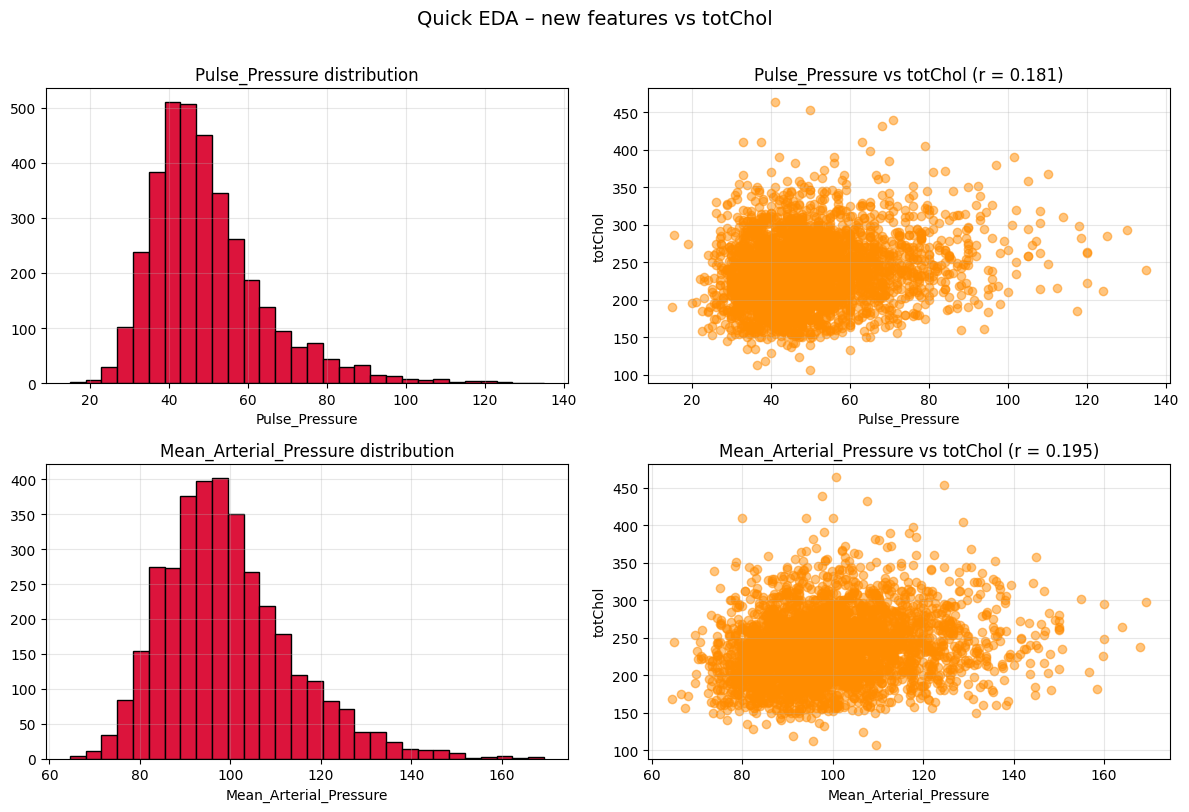

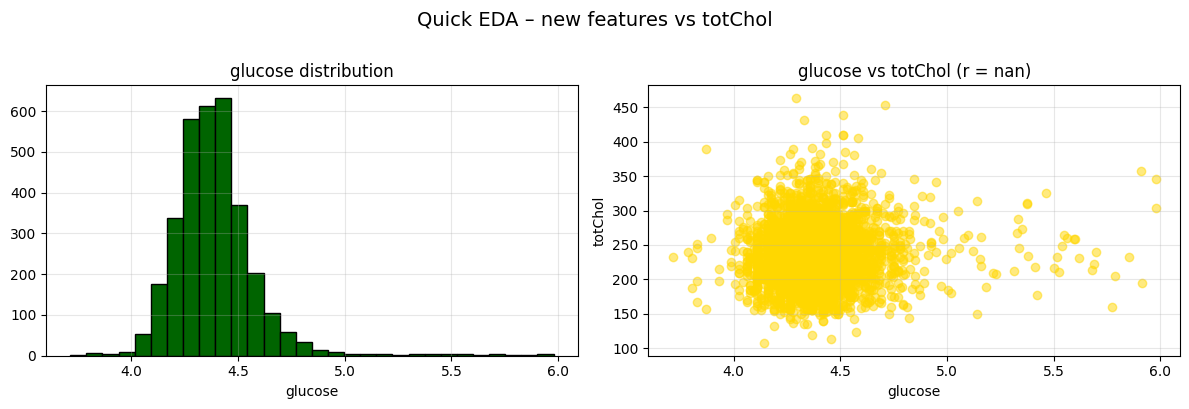

In [9]:
# Quick EDA on the numeric features
# ---------------------------------------------
def plot_features_eda(X, y, features, target_name, hist_c, scat_c, ncols=2):
    """
    For each feature in `features`, create a row with two subplots:
    histogram of the feature (left) and scatter vs target (right).
    """
    nrows = len(features)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    
    # Make sure axes is 2D even for a single row
    if nrows == 1:
        axes = axes.reshape(1, -1)
    
    for i, feat in enumerate(features):
        r, _ = scipy.stats.pearsonr(X[feat], y)
        
        # Histogram
        axes[i, 0].hist(X[feat], bins=30, color=hist_c, edgecolor='k')
        axes[i, 0].set_title(f'{feat} distribution')
        axes[i, 0].set_xlabel(feat)
        axes[i, 0].grid(alpha=0.3)
        
        # Scatter
        axes[i, 1].scatter(X[feat], y, alpha=0.5, color=scat_c)
        axes[i, 1].set_title(f'{feat} vs {target_name} (r = {r:.3f})')
        axes[i, 1].set_xlabel(feat)
        axes[i, 1].set_ylabel(target_name)
        axes[i, 1].grid(alpha=0.3)
    
    plt.suptitle(f'Quick EDA – new features vs {target_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()



# BP features
BP_features = ['Pulse_Pressure', 'Mean_Arterial_Pressure']
plot_features_eda(x_bp_train, y_train, BP_features,
                  'totChol', 'crimson', 'darkorange')

# Glucose feature
glucose_features = ['glucose']
plot_features_eda(x_glucose_train, y_train, glucose_features,
                  'totChol', 'darkgreen', 'gold')


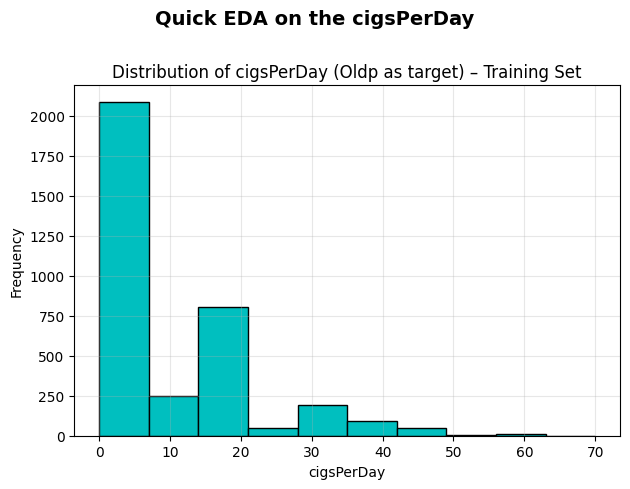

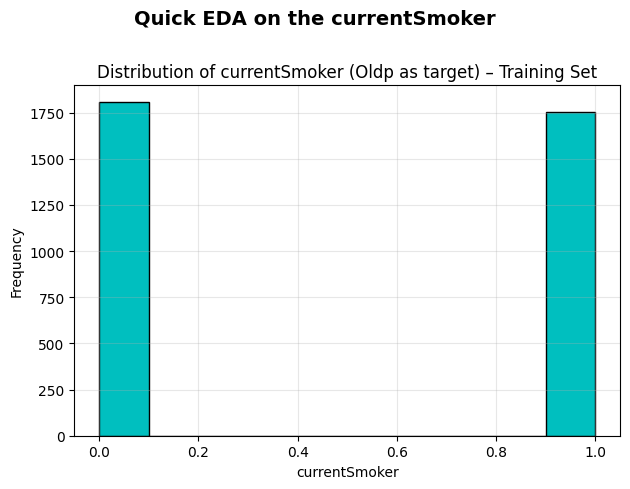

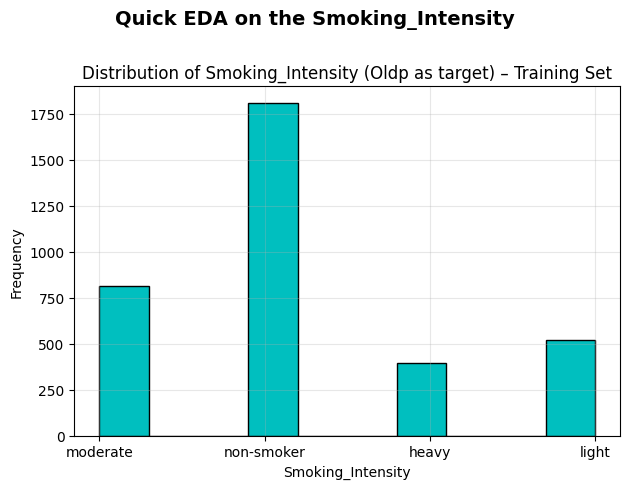

In [ ]:
def plot_cat_dis(X, feat):
    # Histogram of new cat features (training set)
    X[feat].hist(color='c', edgecolor='k')
    plt.title(f'Distribution of {feat} (Oldp as target) – Training Set')
    plt.xlabel(feat)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)


    plt.suptitle(f"Quick EDA on the {feat}", fontsize=14, weight='bold' ,y=1.01)
    plt.tight_layout()
    plt.show()


smoking_features = ['cigsPerDay', 'currentSmoker', 'Smoking_Intensity']
for f in smoking_features:
    plot_cat_dis(x_smoking_train, f)

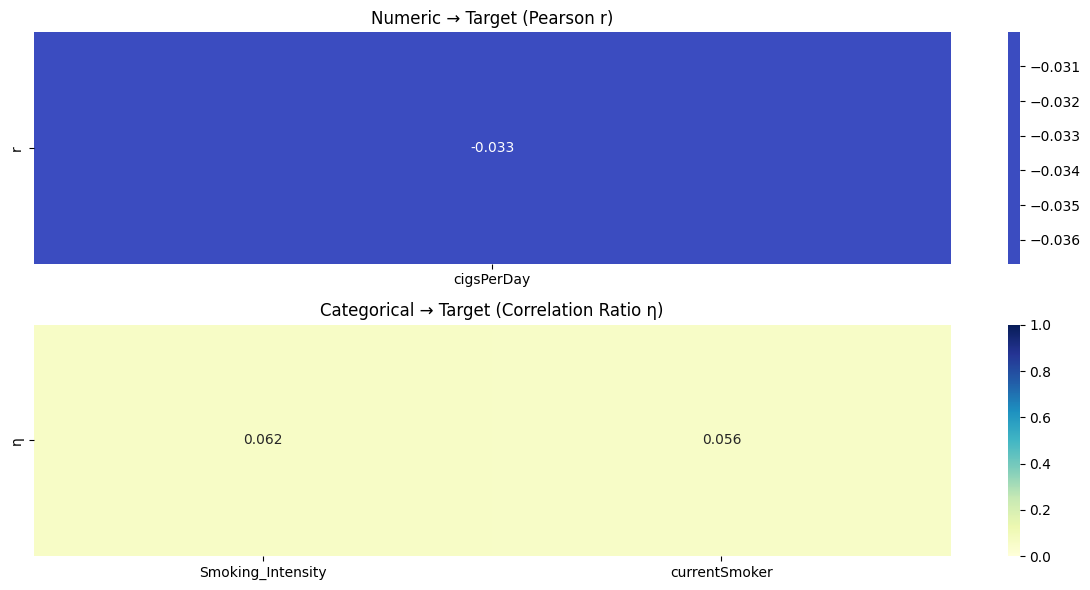

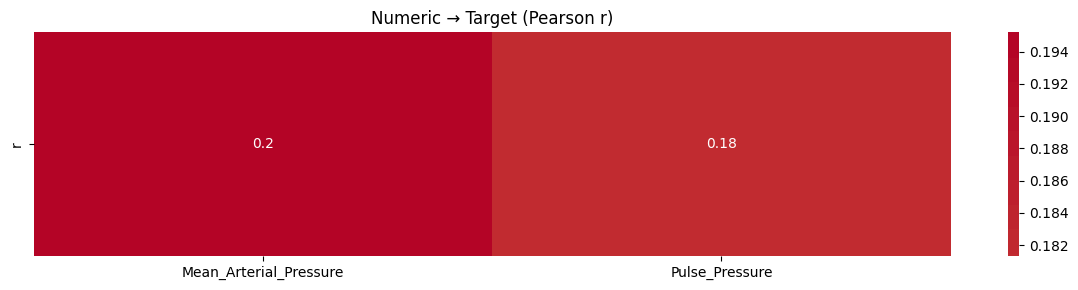

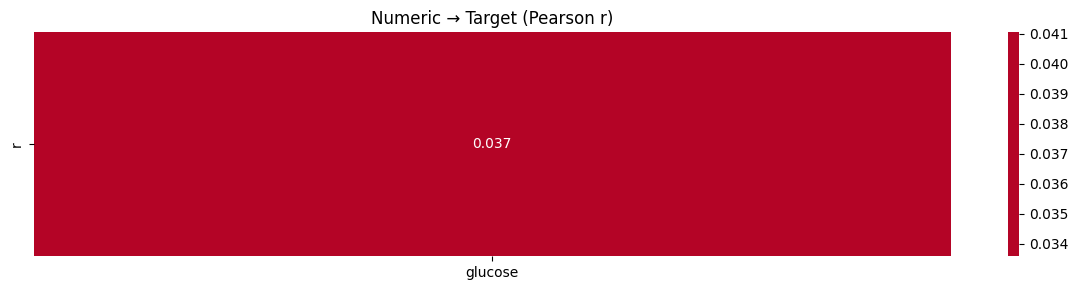

In [9]:
# Create DataFrames that contain the new engineered features AND the target
full_train_ana_sm = x_smoking_train.copy()
full_train_ana_sm['totChol'] = y_train.values

full_train_ana_bp = x_bp_train.copy()
full_train_ana_bp['totChol'] = y_train.values

full_train_ana_gl = x_glucose_train.copy()
full_train_ana_gl['totChol'] = y_train.values

# Now pass them to the analyzer
analyzer_sm = CorrelationAnalyzer(
    data=full_train_ana_sm,
    target_type='numeric',
    num_cols=[smoking_features[0]],
    cat_cols=smoking_features[1:3],
    target_col='totChol'
)

analyzer_bp = CorrelationAnalyzer(
    data=full_train_ana_bp,
    target_type='numeric',
    num_cols=BP_features,
    cat_cols=None,
    target_col='totChol'
)

analyzer_gl = CorrelationAnalyzer(
    data=full_train_ana_gl,
    target_type='numeric',
    num_cols=glucose_features,
    cat_cols=None, 
    target_col='totChol'
)


analyzer_sm.plot_feature_numeric_target()
analyzer_bp.plot_feature_numeric_target()
analyzer_gl.plot_feature_numeric_target()

#### - Check outliers and skewness

In [15]:
skewness_detector(x_glucose_train[['glucose', 'cigsPerDay', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'age']])

,Feature,Skewness,Skewness_Exceeding_Threshold
0,glucose,2.260436,True
1,cigsPerDay,1.237881,True
2,sysBP,1.079584,True
3,BMI,1.035255,True
4,diaBP,0.708472,False
5,heartRate,0.634925,False
6,age,0.232949,False


In [16]:
outlier_detector(x_glucose_train[['glucose', 'cigsPerDay', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'age']])

,Feature,N_outliers,Outlier_pct
0,glucose,119,3.341
1,sysBP,109,3.060
2,BMI,87,2.442
3,diaBP,75,2.106
4,heartRate,63,1.769
5,cigsPerDay,9,0.253
6,age,0,0.000


### 7) Core of preprocessing and handling data


In [11]:
"""

"""

# Identify columns
#------------------

# Basline numeric fetures
baseline_num_features = ['glucose', 'cigsPerDay', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'age']

# Baseline categorical features
baseline_bin_features = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']
baseline_ord_features = ['education']
baseline_nom_features = []

# Smokers eng features -> Same num / 'Smoking_Intensity' added to ord
sm_ord_features = [
    'education',
    'Smoking_Intensity'
]

# BP eng features -> Same cat / 'Pulse_Pressure', 'Mean_Arterial_Pressure' added to num
bp_num_features = baseline_num_features + BP_features


# Continuos numeric Pipelines
#------------------------------

# Continuous numeric Pipeline 
con_num_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical Pipelines
#------------------------------

# Binary features Pipeline
bin_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Ordinal features Pipeline
# General
ord_Pipeline = Pipeline(([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
]))

# Smoking eng specific
ord_Pipeline_sm = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oe_encoder",
     OrdinalEncoder(
         categories=[
             [1,2,3,4],  # education
             ["non-smoker", "light", "moderate", "heavy"]
         ]
     ))
])

# Nominal features Pipeline
nom_Pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe_encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine all Pipelines to build the full preprocessor
#------------------------------------------------------

#-----  Baseline -----

# The column transformer to perform feature engineering
preprocessor_baseline = ColumnTransformer([
    ("con_num", con_num_Pipeline, baseline_num_features),
    ("bin", bin_Pipeline, baseline_bin_features),
    ("nom", nom_Pipeline, baseline_nom_features),
    ("ord", ord_Pipeline, baseline_ord_features)
], remainder="drop")

#----- SM Eng -----

# The column transformer to perform feature engineering
preprocessor_sm = ColumnTransformer([
    ("con_num", con_num_Pipeline, baseline_num_features),
    ("bin", bin_Pipeline, baseline_bin_features),
    ("nom", nom_Pipeline, baseline_nom_features),
    ("ord", ord_Pipeline_sm, sm_ord_features)
], remainder="drop")

#----- BP Eng -----

# The column transformer to perform feature engineering
preprocessor_bp = ColumnTransformer([
    ("con_num", con_num_Pipeline, bp_num_features),
    ("bin", bin_Pipeline, baseline_bin_features),
    ("nom", nom_Pipeline, baseline_nom_features),
    ("ord", ord_Pipeline, baseline_ord_features)
], remainder="drop")



print("-----Preprocessing with pipelines done-----")


-----Preprocessing with pipelines done-----


####  - Fit on the full training data and transform  

In [12]:
# Baseline
#-----------------------------

# Fit on the entire training set 
preprocessor_baseline.fit(X_TRAIN)

# Transform both training and test sets
X_train_prep_baseline = preprocessor_baseline.transform(X_TRAIN).astype(np.float32)
X_test_prep_baseline  = preprocessor_baseline.transform(X_TEST).astype(np.float32)

# Targets
y_train_baseline = y_train.values
y_test_baseline  = y_test.values

print("Baseline:")
print("X_train_prep shape:", X_train_prep_baseline.shape)
print("X_test_prep shape:",  X_test_prep_baseline.shape)

Baseline:
X_train_prep shape: (3562, 15)
X_test_prep shape: (624, 15)


In [19]:
# Smoking eng
#-----------------------------

# Fit on the entire training set 
preprocessor_sm.fit(x_smoking_train)

# Transform both training and test sets
X_train_prep_sm = preprocessor_sm.transform(x_smoking_train).astype(np.float32)
X_test_prep_sm  = preprocessor_sm.transform(x_smoking_test).astype(np.float32)

# Targets
y_train_sm = y_train.values
y_test_sm  = y_test.values

print("Smoking Eng:")
print("X_train_prep shape:", X_train_prep_sm.shape)
print("X_test_prep shape:",  X_test_prep_sm.shape)

Smoking Eng:
X_train_prep shape: (3562, 16)
X_test_prep shape: (624, 16)


In [20]:
# sys / dia Blodd Pressure eng
#-----------------------------

# Fit on the entire training set 
preprocessor_bp.fit(x_bp_train)

# Transform both training and test sets
X_train_prep_bp = preprocessor_bp.transform(x_bp_train).astype(np.float32)
X_test_prep_bp  = preprocessor_bp.transform(x_bp_test).astype(np.float32)

# Targets
y_train_bp = y_train.values
y_test_bp  = y_test.values

print("BP Eng:")
print("X_train_prep shape:", X_train_prep_bp.shape)
print("X_test_prep shape:",  X_test_prep_bp.shape)

BP Eng:
X_train_prep shape: (3562, 17)
X_test_prep shape: (624, 17)


In [21]:
# Glucose eng
#-----------------------------

# Fit on the entire training set 
preprocessor_baseline.fit(x_glucose_train)

# Transform both training and test sets
X_train_prep_glucose = preprocessor_baseline.transform(x_glucose_train).astype(np.float32)
X_test_prep_glucose  = preprocessor_baseline.transform(x_glucose_test).astype(np.float32)

# Targets
y_train_glucose = y_train.values
y_test_glucose  = y_test.values

print("Glucose Eng (log transformation):")
print("X_train_prep shape:", X_train_prep_glucose.shape)
print("X_test_prep shape:",  X_test_prep_glucose.shape)

Glucose Eng (log transformation):
X_train_prep shape: (3562, 15)
X_test_prep shape: (624, 15)


In [ ]:
# NaNs check
print(np.isnan(X_train_prep_baseline).sum())
print(np.isnan(X_train_prep_sm).sum())
print(np.isnan(X_train_prep_bp).sum())
print(np.isnan(X_train_prep_glucose).sum())

0
0
0
0


### 8) Model Benchmarking 

In [ ]:
# Initialize the models
models = {
    'AdaBoost Regressor': AdaBoostRegressor(random_state=RANDOM_STATE),
    'Extra Trees Regressor': ExtraTreesRegressor(random_state=RANDOM_STATE),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Random Forest Regressor': RandomForestRegressor(random_state=RANDOM_STATE),
    'Elastic Net': ElasticNet(random_state=RANDOM_STATE),
    'RANSAC Regressor': RANSACRegressor(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Linear Regression': LinearRegression(),
    'Huber Regressor': HuberRegressor(),
    'SVR': SVR(),
    'K-Neighbors Regressor': KNeighborsRegressor()
    #'Gaussian Process Regressor': GaussianProcessRegressor(), takes too much time to train
}


# Scoring metrics: we'll compute RMSE manually from neg_mean_squared_error, and use r2 directly
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error'
}

def model_benchmark(models, X, y, scoring):
    # Cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    results = []

    for name, model in models.items():
        regressor = clone(model)

        # cross_validate
        cv_results = cross_validate(
            regressor, X, y,
            cv=cv, scoring=scoring,
            return_train_score=False, n_jobs=-1
        )
        
        # Extract mean and std of each metric
        # If using neg_root_mean_squared_error:
        rmse_mean = -cv_results['test_RMSE'].mean()
        rmse_std  = (-cv_results['test_RMSE']).std()
        r2_mean   =  cv_results['test_R2'].mean()
        r2_std    =  cv_results['test_R2'].std()
        mae_mean  = -cv_results['test_MAE'].mean()
        mae_std   =  cv_results['test_MAE'].std()
        
        results.append({
            "Model": name,
            "R2_mean": r2_mean,
            "R2_std": r2_std,
            "RMSE_mean": rmse_mean,
            "RMSE_std": rmse_std,
            "MAE_mean": mae_mean, 
            "MAE_std": mae_std
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    # Sort by R² descending
    results_df = results_df.sort_values(by='R2_mean', ascending=False).reset_index(drop=True)
    return results_df


# Apply
baseline_results = model_benchmark(models, X_train_prep_baseline, y_train_baseline, scoring)
sm_results = model_benchmark(models, X_train_prep_sm, y_train_sm, scoring)
bp_results = model_benchmark(models, X_train_prep_bp, y_train_bp, scoring)
glucose_results = model_benchmark(models, X_train_prep_glucose, y_train_glucose, scoring)


print('----- Benchmarking results saved -----')

----- Benchmarking results saved -----


#### - Results of models on training sets

In [24]:
baseline_results

,Model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,Gradient Boosting Regressor,0.111016,0.027478,41.009165,1.902727,31.919404,1.283233
1,SVR,0.107724,0.022950,41.092642,2.007325,31.736952,1.510163
2,Ridge,0.087157,0.022618,41.554869,1.838516,32.321937,1.450884
3,Linear Regression,0.087065,0.022743,41.556951,1.839813,32.324499,1.451501
4,Lasso,0.086677,0.016935,41.572401,1.921739,32.362616,1.487171
5,Huber Regressor,0.084525,0.026876,41.615903,1.922770,32.195854,1.490903
6,Elastic Net,0.081508,0.013676,41.690241,1.907434,32.507672,1.477198
7,Random Forest Regressor,0.076276,0.035654,41.786955,1.735692,32.549182,1.175080
8,Extra Trees Regressor,0.047243,0.033517,42.433441,1.565275,33.055435,0.881349
9,AdaBoost Regressor,0.045010,0.041240,42.463724,1.162768,33.582640,1.059056


In [25]:
sm_results

,Model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,Gradient Boosting Regressor,0.110449,0.028547,41.021709,1.908209,31.924972,1.286119
1,SVR,0.105919,0.022908,41.134775,2.020589,31.775007,1.519653
2,Ridge,0.087344,0.022183,41.550478,1.830113,32.313997,1.439298
3,Linear Regression,0.087245,0.022299,41.552704,1.831222,32.316689,1.439619
4,Lasso,0.086670,0.016901,41.572520,1.920801,32.362488,1.486124
5,Huber Regressor,0.084630,0.026205,41.613278,1.908737,32.198331,1.472355
6,Elastic Net,0.081492,0.013661,41.690596,1.907014,32.508037,1.476696
7,Random Forest Regressor,0.075363,0.032569,41.808866,1.701381,32.558901,1.149720
8,Extra Trees Regressor,0.045849,0.037286,42.460713,1.549335,33.023814,0.771348
9,AdaBoost Regressor,0.043131,0.025318,42.535324,1.666512,33.714320,1.417453


In [26]:
bp_results

,Model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,Gradient Boosting Regressor,0.107086,0.031294,41.098396,1.943048,31.947824,1.362586
1,SVR,0.103551,0.022215,41.189565,2.020553,31.811305,1.500529
2,Ridge,0.087156,0.022617,41.554895,1.838525,32.321947,1.450893
3,Linear Regression,0.087065,0.022743,41.556951,1.839812,32.324499,1.451500
4,Lasso,0.086885,0.017195,41.567802,1.926906,32.359698,1.490068
5,Huber Regressor,0.084520,0.026872,41.616023,1.922736,32.195997,1.490804
6,Elastic Net,0.081516,0.013011,41.690334,1.908470,32.497869,1.490248
7,Random Forest Regressor,0.080171,0.039020,41.699435,1.829126,32.498871,1.224190
8,Extra Trees Regressor,0.048613,0.036801,42.396703,1.467957,33.099214,0.803660
9,AdaBoost Regressor,0.036167,0.045166,42.667584,1.513344,33.816819,1.473080


In [27]:
glucose_results

,Model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
0,Gradient Boosting Regressor,0.110953,0.027552,41.010659,1.904703,31.921942,1.284736
1,SVR,0.106045,0.022986,41.131104,2.005734,31.768363,1.509440
2,Ridge,0.087382,0.022777,41.549665,1.838056,32.321446,1.446030
3,Linear Regression,0.087295,0.022902,41.551623,1.839329,32.323886,1.446560
4,Lasso,0.086677,0.016935,41.572401,1.921739,32.362615,1.487172
5,Huber Regressor,0.084716,0.027010,41.611304,1.918674,32.194741,1.485994
6,Elastic Net,0.081492,0.013641,41.690566,1.906029,32.507447,1.476796
7,Random Forest Regressor,0.076003,0.035679,41.793637,1.748153,32.551138,1.184155
8,AdaBoost Regressor,0.068612,0.023246,41.961861,1.550468,33.254803,1.242409
9,Extra Trees Regressor,0.048964,0.040377,42.398641,1.803533,33.026347,1.000006


#### - The results of benchmarking visualized

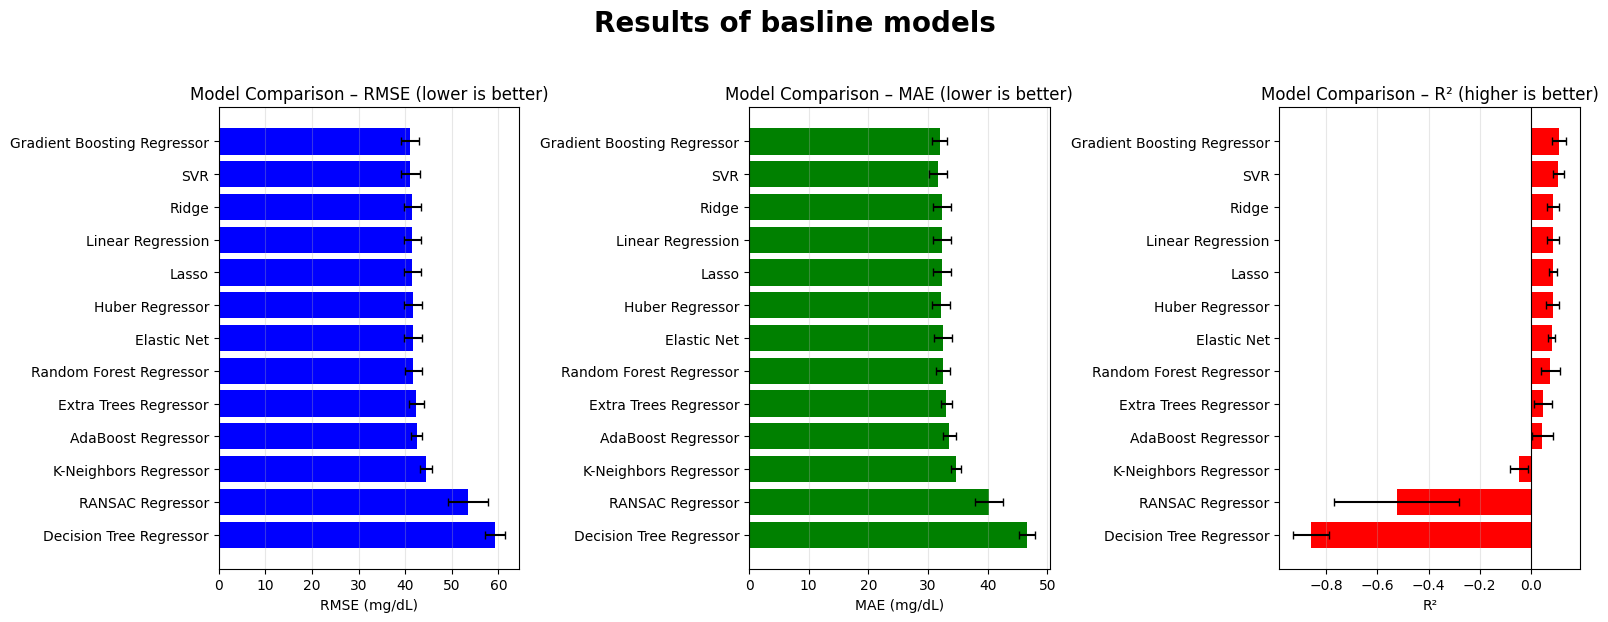

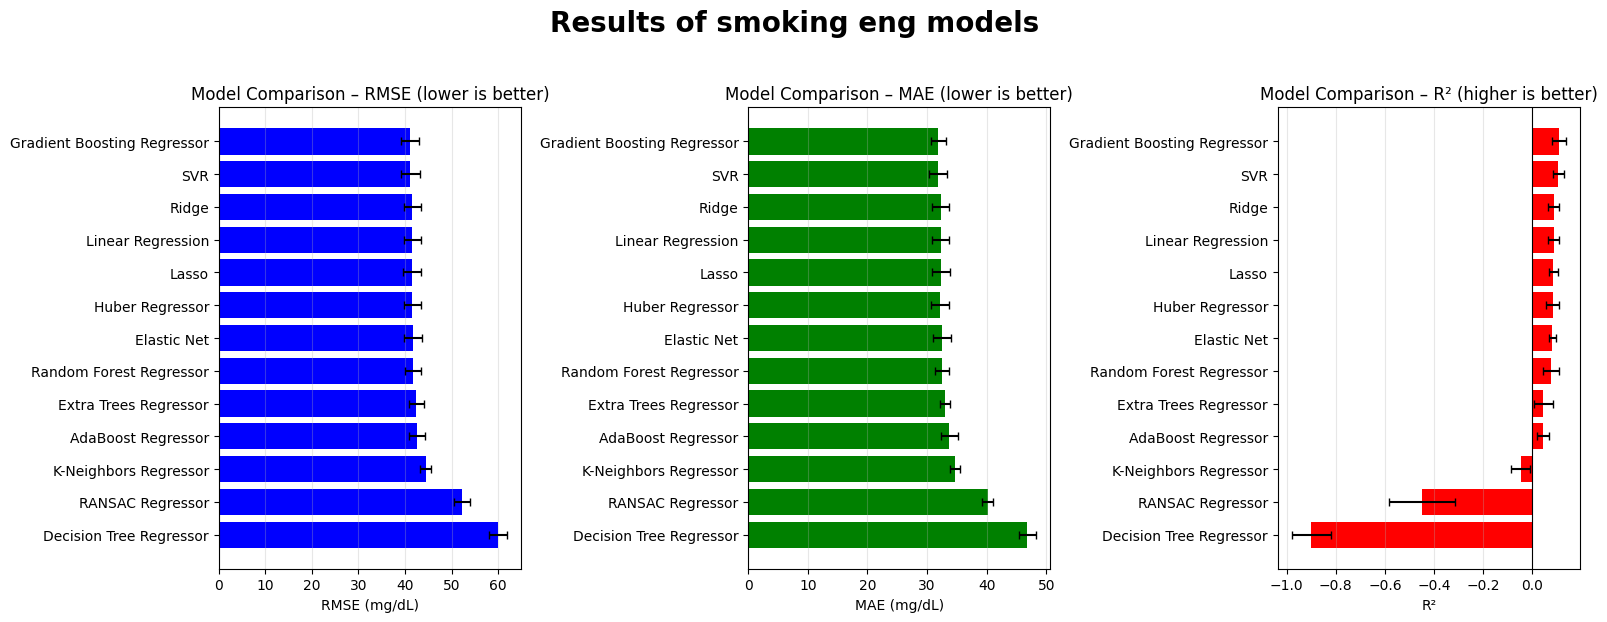

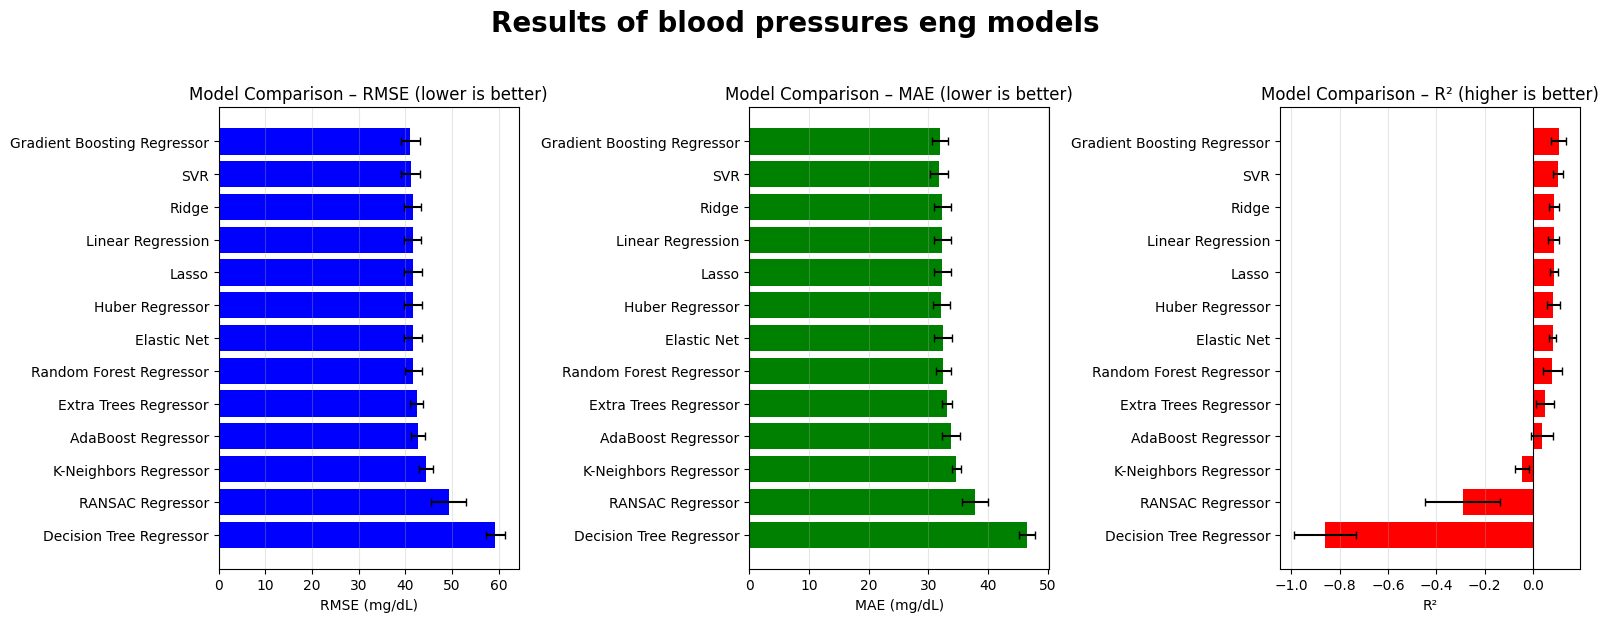

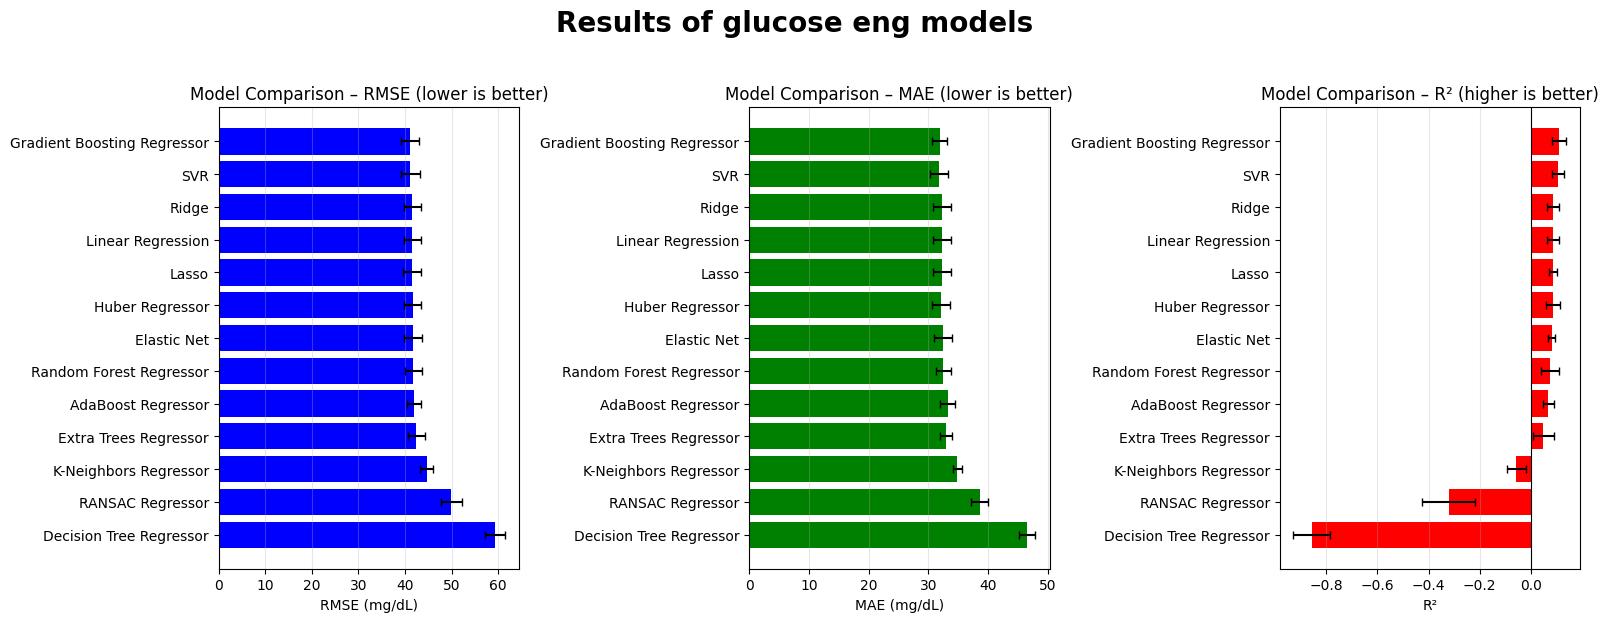

In [30]:
def plot_benchmarking_results(df, m):

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

    # --- RMSE ---
    ax1.barh(df['Model'], df['RMSE_mean'],
            xerr=df['RMSE_std'], color='b', capsize=3)
    ax1.set_xlabel('RMSE (mg/dL)')
    ax1.set_title('Model Comparison – RMSE (lower is better)')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)

    # --- MAE ---
    ax2.barh(df['Model'], df['MAE_mean'],
            xerr=df['MAE_std'], color='g', capsize=3)
    ax2.set_xlabel('MAE (mg/dL)')
    ax2.set_title('Model Comparison – MAE (lower is better)')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)

    # --- R² ---
    ax3.barh(df['Model'], df['R2_mean'],
            xerr=df['R2_std'], color='r', capsize=3)
    ax3.axvline(0, color='black', linewidth=0.8)
    ax3.set_xlabel('R²')
    ax3.set_title('Model Comparison – R² (higher is better)')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)

    plt.suptitle(f"Results of {m}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


plot_benchmarking_results(baseline_results, 'basline models')
plot_benchmarking_results(sm_results, 'smoking eng models')
plot_benchmarking_results(bp_results, 'blood pressures eng models')
plot_benchmarking_results(glucose_results, 'glucose eng models')

#### -  Predicted‑vs‑actual scatter for top‑3 regressors

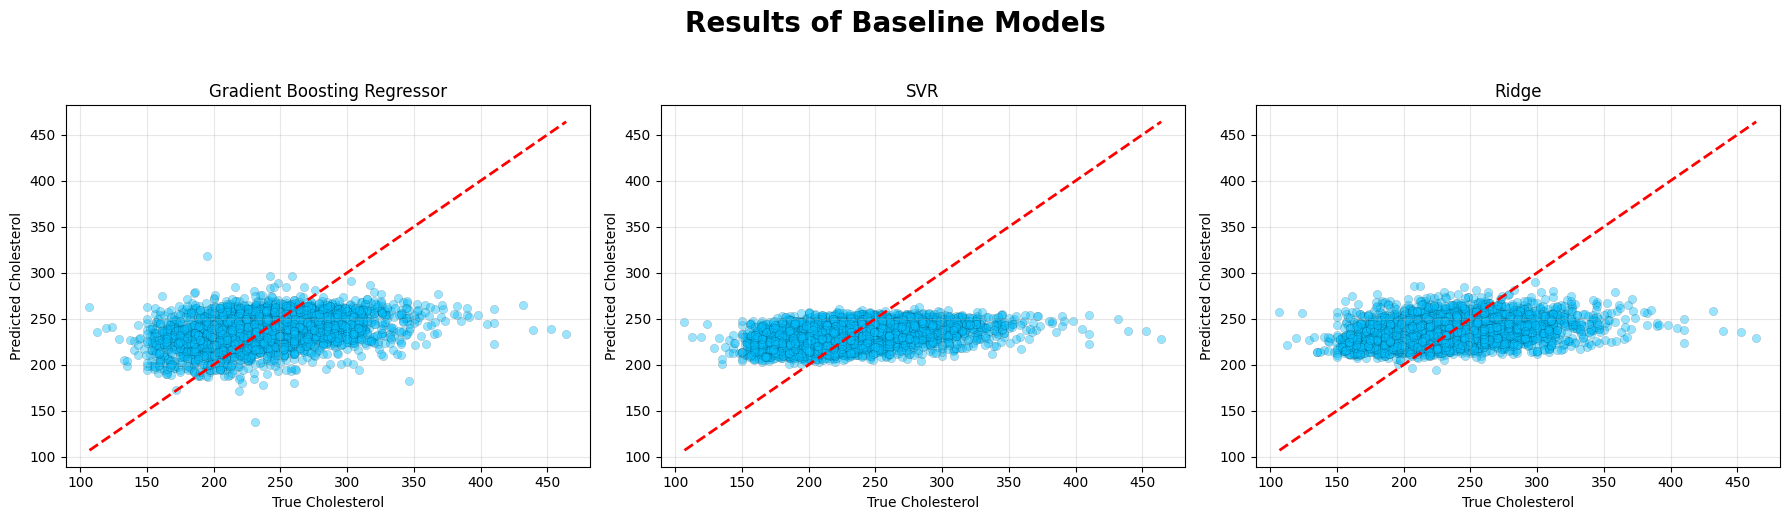

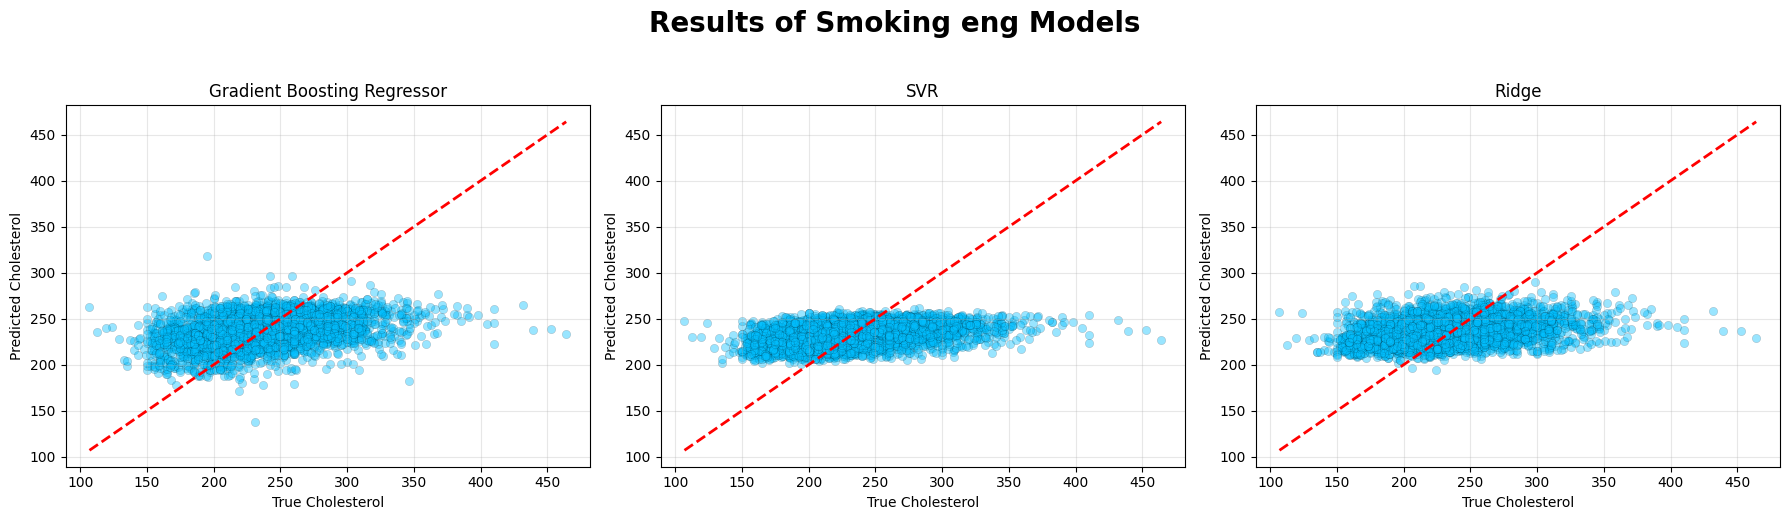

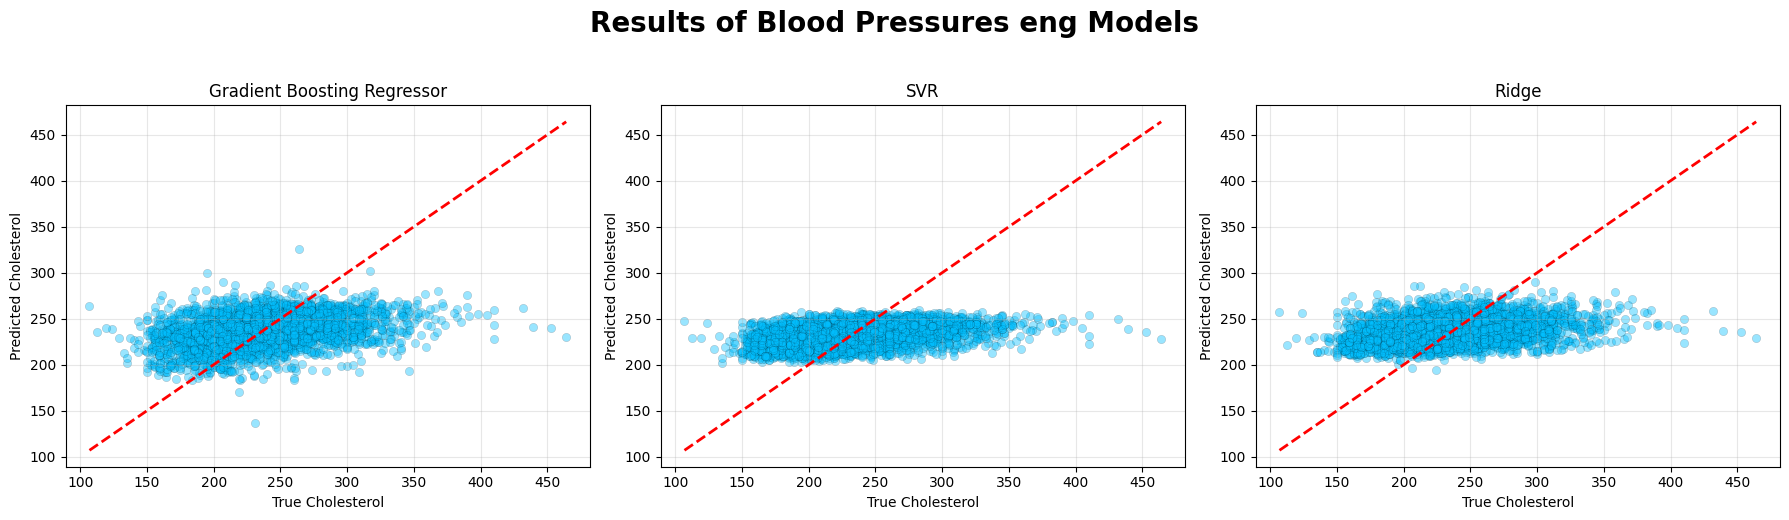

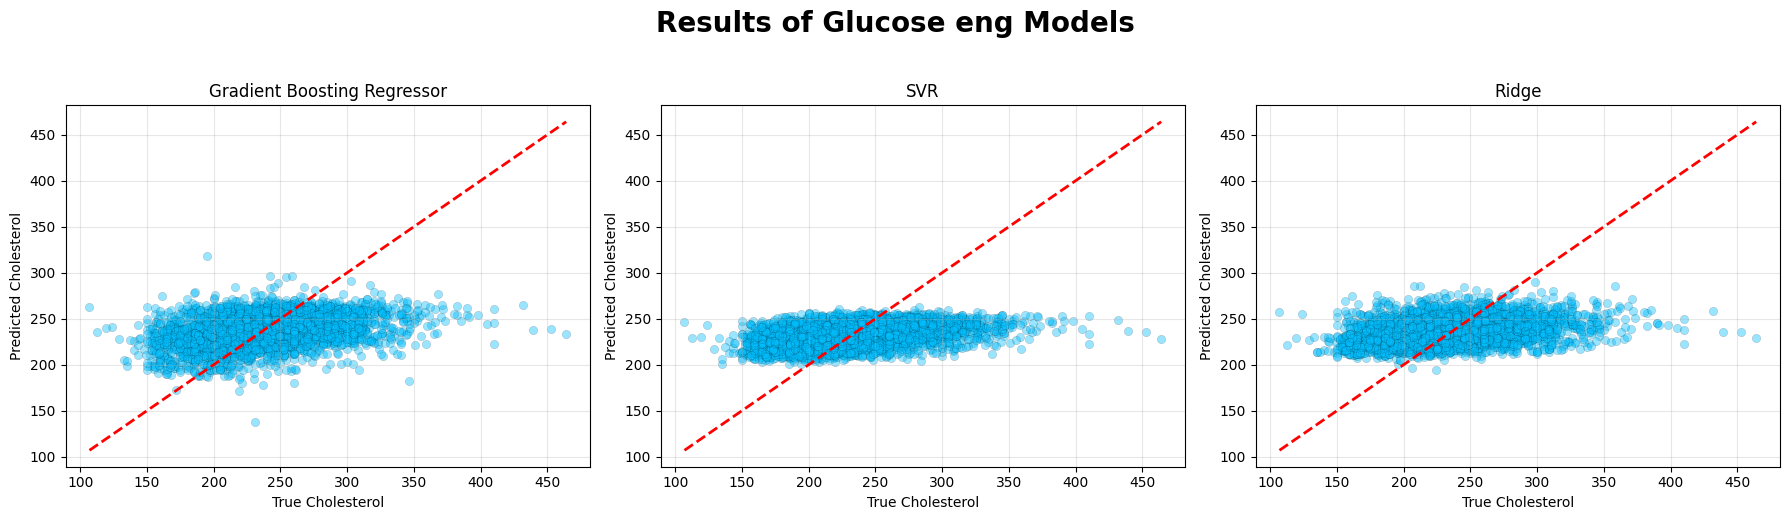

In [ ]:
def plot_pred_vs_act(df, X, y, text):
    # Choose top 3 models by R2_mean (from results_df)
    top3_names = df['Model'].head(3).tolist()
    top3_models = {name: models[name] for name in top3_names}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (name, model) in zip(axes, top3_models.items()):
        reg = clone(model)
        y_cv_pred = cross_val_predict(reg, X, y,
                                    cv=5, n_jobs=-1)
        ax.scatter(y, y_cv_pred, alpha=0.4, edgecolors='k', color='deepskyblue', linewidth=0.2)
        ax.plot([y.min(), y.max()],
                [y.min(), y.max()], 'r--', lw=2)
        ax.set_xlabel('True Cholesterol')
        ax.set_ylabel('Predicted Cholesterol')
        ax.set_title(name)
        ax.grid(alpha=0.3)

    plt.suptitle(f"Results of {text}", fontsize=20, y=1.03, weight='bold')

    plt.tight_layout()
    plt.show()


plot_pred_vs_act(baseline_results, X_train_prep_baseline, y_train_baseline, 'Baseline Models')
plot_pred_vs_act(sm_results, X_train_prep_sm, y_train_sm, 'Smoking eng Models')
plot_pred_vs_act(bp_results, X_train_prep_bp, y_train_bp, 'Blood Pressures eng Models')
plot_pred_vs_act(glucose_results, X_train_prep_glucose, y_train_glucose, 'Glucose eng Models')

### 9) The final training on the full train set 
> The best candidate compared to others - Gradient Boosting Regressor

In [13]:
# fit-transform, and preprocessing have been done before
final_model = GradientBoostingRegressor(random_state=RANDOM_STATE) # default hyperparameters
final_model.fit(X_train_prep_baseline, y_train_baseline)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### 10) The final evaluation on the test set

#### - Fundamental evaluation metrics

In [14]:
# Predict on the test set
y_pred_baseline = final_model.predict(X_test_prep_baseline)

# Compute evaluation metrics (RMSE - MAE - R²)
rmse = np.sqrt(mean_squared_error(y_test_baseline, y_pred_baseline))
mae = mean_absolute_error(y_test_baseline, y_pred_baseline)
r2 = r2_score(y_test_baseline, y_pred_baseline)

print(f"Test set performance (Gradient Boosting Regressor):")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"R²:   {r2:.4f}")

Test set performance (Gradient Boosting Regressor):
RMSE: 41.07 mg/dL
MAE:  32.49 mg/dL
R²:   0.1400


#### -  Plot predicted vs actual (test set)

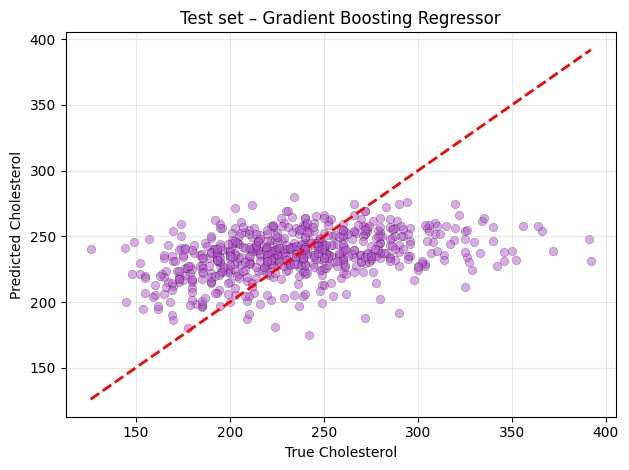

In [37]:
# Plot
plt.scatter(y_test_baseline, y_pred_baseline, alpha=0.5, edgecolors='k', color='mediumorchid', linewidth=0.3)
plt.plot([y_test_baseline.min(), y_test_baseline.max()], [y_test_baseline.min(), y_test_baseline.max()], 'r--', lw=2)
plt.xlabel('True Cholesterol')
plt.ylabel('Predicted Cholesterol')
plt.title('Test set – Gradient Boosting Regressor')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
#--------------------------------------------
# Save the model & preprocessing pipeline
#--------------------------------------------

joblib.dump(final_model, PROJECT_ROOT / "Models/Regression/totChol_model.joblib")
print("Model Saved: totChol_model.joblib")

Model Saved: totChol_model.joblib


## Conclusion – Cholesterol Regression on the Framingham Dataset

In this regression investigation, the objective was to predict **total cholesterol (totChol)** using demographic, lifestyle, and cardiovascular risk factors from the Framingham Heart Study dataset.

* **Baseline regression performance** – Across a diverse collection of machine learning algorithms, including linear models, support vector regression, ensemble methods, and instance-based learners, the best cross-validated performance was obtained by the Gradient Boosting Regressor with **R² ≈ 0.11**. Performance remained consistently low across all model families, suggesting that the available predictors contain only limited information about individual cholesterol levels.

* **Feature engineering experiments** – Several clinically motivated feature-engineering strategies were evaluated:

  * Smoking intensity categories derived from cigarette consumption.
  * Blood-pressure-derived variables, including Pulse Pressure and Mean Arterial Pressure.
  * Log transformation of glucose measurements to reduce skewness.

  None of these engineered features produced a meaningful improvement over the baseline model. Cross-validated performance differences were negligible, indicating that the primary limitation lies in the available predictive signal rather than the feature representation.

* **Model comparison and robustness** – The consistency of results across linear, robust, kernel-based, and ensemble regressors strengthens confidence in the findings. The low predictive performance was not specific to a single algorithm but was observed throughout the benchmarking process.

* **Held-out test evaluation** – The final Gradient Boosting Regressor achieved:

  * **RMSE ≈ 41 mg/dL**
  * **MAE ≈ 32 mg/dL**
  * **R² ≈ 0.14**

  on the independent test set. The similarity between cross-validation and test-set performance indicates that the model generalized as expected and did not suffer from substantial overfitting.

### Key take-away

This study demonstrates an important methodological lesson: even when a rigorous machine-learning workflow is applied—including data cleaning, exploratory analysis, preprocessing pipelines, feature engineering, cross-validation, benchmarking, and final testing—predictive performance ultimately depends on the relationship between the target variable and the available predictors.

The framework successfully:

* Produced reproducible and unbiased model evaluations.
* Identified the practical limits of cholesterol prediction from the available features.
* Demonstrated the value of systematic benchmarking and validation.
* Documented a meaningful negative result rather than forcing an overly optimistic conclusion.

Together with the previous regression experiments, these findings suggest that successful predictive modeling requires not only a robust methodology but also datasets whose features contain sufficient information about the target of interest.

In the next stage, the framework will be applied to a dataset specifically designed for a regression task, allowing evaluation of the same methodology on a problem where stronger predictive relationships are expected and higher predictive performance is achievable.
